# 11. Fidelity Measuring

Avaliação de **fidelidade** (fidelity) das explicações locais LIME e SHAP via **deleção iterativa de atributos**.

O protocolo concentra-se nas instâncias de holdout onde o LightGBM mais errou (`sample_bucket = 'bad'`), pois a fidelidade da explicação é metodologicamente mais relevante quando a previsão falha.

In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import sys
from pathlib import Path
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))

from src.utils.helpers import load_pickle
from src.evaluation.fidelity import get_local_ranking, evaluate_local_fidelity

In [24]:
#Load model and data
artifact_dir = Path('../experiments/exp_001_lgbm/artifacts')

store_filter = ['CA_1', 'TX_1']
if isinstance(store_filter, (list, tuple, set, pd.Index)):
    store_suffix = '_'.join(map(str, store_filter))
else:
    store_suffix = store_filter if store_filter else 'all_stores'

model_path = artifact_dir / f'lightgbm_{store_suffix}.pkl'
model = load_pickle(model_path)

x_train_path = artifact_dir / f"X_train_{store_suffix}.parquet"
X_train = pd.read_parquet(x_train_path)

x_test_path = artifact_dir / f'X_test_predict_{store_suffix}.parquet'
X_test = pd.read_parquet(x_test_path)

shap_path = artifact_dir / f"shap_explanation_{store_suffix}.parquet"
shap_explanations = pd.read_parquet(shap_path)

lime_path = artifact_dir / f"lime_explanations_{store_suffix}.parquet"
lime_explanations = pd.read_parquet(lime_path)

sample_path = artifact_dir / f'sample_{store_suffix}.parquet'
selected_predictions = pd.read_parquet(sample_path)

#Configuration
steps = (1, 3, 5, 10)
num_samples = 100
random_state = 42

Loaded from ..\experiments\exp_001_lgbm\artifacts\lightgbm_CA_1_TX_1.pkl


In [ ]:
shap_results = []

for instance_id in shap_explanations["instance_id"].unique():

    instance = X_test.loc[[instance_id]]

    ranking = get_local_ranking(
        explanations_df=shap_explanations,
        instance_id=instance_id,
    )

    fidelity = evaluate_local_fidelity(
        model=model,
        instance=instance,
        reference_data=X_train,
        ranked_features=ranking,
        steps=steps,
        num_samples=num_samples,
        random_state=random_state,
    )

    fidelity["instance_id"] = instance_id
    fidelity["method"] = "SHAP"

    shap_results.append(fidelity)

shap_fidelity = pd.concat(
    shap_results,
    ignore_index=True,
)

shap_fidelity.head()

,k,baseline_prediction,mean_prediction_change,instance_id,method
0,1,0.998000,0.578958,25407,SHAP
1,3,0.998000,1.010160,25407,SHAP
2,5,0.998000,1.101736,25407,SHAP
3,10,0.998000,1.115332,25407,SHAP
4,1,0.999696,0.759204,35336,SHAP


In [11]:
lime_results = []

for instance_id in lime_explanations["instance_id"].unique():

    instance = X_test.loc[[instance_id]]

    ranking = get_local_ranking(
        explanations_df=lime_explanations,
        instance_id=instance_id,
    )

    fidelity = evaluate_local_fidelity(
        model=model,
        instance=instance,
        reference_data=X_train,
        ranked_features=ranking,
        steps=steps,
        num_samples=num_samples,
        random_state=random_state,
    )

    fidelity["instance_id"] = instance_id
    fidelity["method"] = "LIME"

    lime_results.append(fidelity)

lime_fidelity = pd.concat(
    lime_results,
    ignore_index=True,
)

lime_fidelity.head()

,k,baseline_prediction,mean_prediction_change,instance_id,method
0,1,0.998000,0.578958,25407,LIME
1,3,0.998000,0.634191,25407,LIME
2,5,0.998000,0.650541,25407,LIME
3,10,0.998000,0.693554,25407,LIME
4,1,0.999696,0.759204,35336,LIME


In [12]:
fidelity_results = pd.concat(
    [
        shap_fidelity,
        lime_fidelity,
    ],
    ignore_index=True,
)

fidelity_results.head(10)

,k,baseline_prediction,mean_prediction_change,instance_id,method
0,1,0.998000,0.578958,25407,SHAP
1,3,0.998000,1.010160,25407,SHAP
2,5,0.998000,1.101736,25407,SHAP
3,10,0.998000,1.115332,25407,SHAP
4,1,0.999696,0.759204,35336,SHAP
5,3,0.999696,1.058501,35336,SHAP
6,5,0.999696,1.123521,35336,SHAP
7,10,0.999696,1.136088,35336,SHAP
8,1,1.000578,0.782638,117457,SHAP
9,3,1.000578,0.759075,117457,SHAP


In [13]:
fidelity_summary = (
    fidelity_results
    .groupby(["method", "k"])
    ["mean_prediction_change"]
    .agg([
        "mean",
        "median",
        "std",
    ])
    .reset_index()
)

fidelity_summary

,method,k,mean,median,std
0,LIME,1,3.261191,0.988098,4.428104
1,LIME,3,6.115134,2.199265,8.826704
2,LIME,5,8.591608,2.473550,12.730099
3,LIME,10,9.636523,2.529026,14.145643
4,SHAP,1,8.245748,1.342512,13.816217
5,SHAP,3,10.041395,2.352297,15.503667
6,SHAP,5,10.289194,2.513778,15.533187
7,SHAP,10,10.346161,2.565959,15.395651


In [14]:
fidelity_results.to_parquet(
    artifact_dir / f"fidelity_local_{store_suffix}.parquet",
    index=False,
)

fidelity_summary.to_parquet(
    artifact_dir / f"fidelity_local_summary_{store_suffix}.parquet",
    index=False,
)

# Analysis

In [17]:
import matplotlib.pyplot as plt

fidelity_results = pd.read_parquet(artifact_dir / f"fidelity_local_{store_suffix}.parquet")
fidelity_summary = pd.read_parquet(artifact_dir / f"fidelity_local_summary_{store_suffix}.parquet")



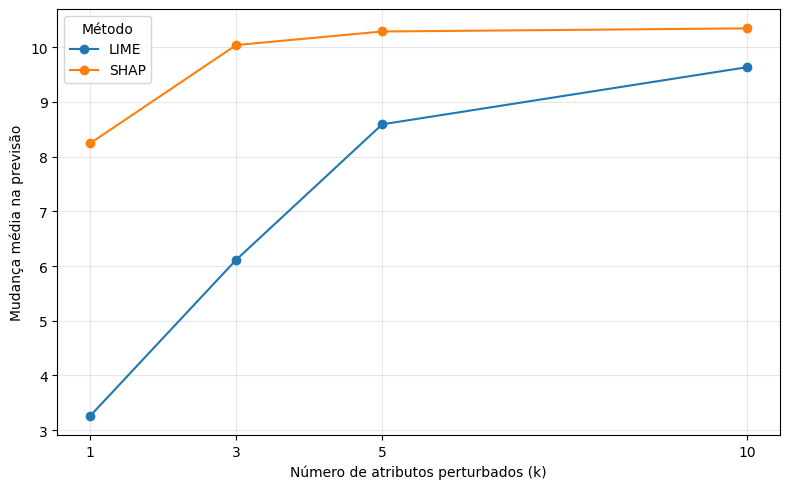

In [18]:
plt.figure(figsize=(8, 5))

for method, df_method in fidelity_summary.groupby('method'):
    plt.plot(
        df_method['k'],
        df_method['mean'],
        marker='o',
        label=method
    )

plt.xlabel('Número de atributos perturbados (k)')
plt.ylabel('Mudança média na previsão')
plt.xticks(sorted(fidelity_summary['k'].unique()))
plt.legend(title='Método')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

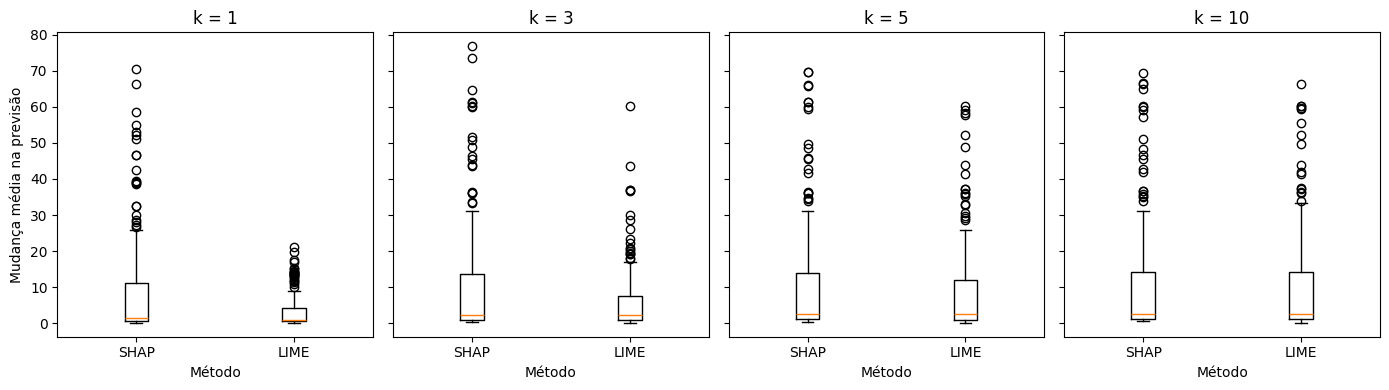

In [19]:

ks = sorted(fidelity_results['k'].unique())
methods = ['SHAP', 'LIME']

fig, axes = plt.subplots(
    1,
    len(ks),
    figsize=(14, 4),
    sharey=True
)

for ax, k in zip(axes, ks):

    data = [
        fidelity_results[
            (fidelity_results['k'] == k) &
            (fidelity_results['method'] == method)
        ]['mean_prediction_change']
        for method in methods
    ]

    ax.boxplot(data, tick_labels=methods)
    ax.set_title(f'k = {k}')
    ax.set_xlabel('Método')

axes[0].set_ylabel('Mudança média na previsão')

plt.tight_layout()
plt.show()

In [23]:
shap_explanations

,instance_id,feature,feature_value,importance,abs_importance
0,25407,cat_id,FOODS,0.000058,0.000058
1,25407,dept_id,FOODS_2,0.002443,0.002443
2,25407,item_id,FOODS_2_293,-0.002931,0.002931
3,25407,state_id,TX,-0.003349,0.003349
4,25407,store_id,TX_1,-0.001176,0.001176
...,...,...,...,...,...
4395,38536,sales_lag_28,36.0,0.380373,0.380373
4396,38536,rolling_mean_7_sales_lag_28,20.140625,-0.007147,0.007147
4397,38536,rolling_mean_28_sales_lag_28,19.359375,0.431688,0.431688
4398,38536,rolling_mean_7,15.581276473459647,13.168070,13.168070


In [25]:
fidelity_analysis = fidelity_results.merge(
    selected_predictions[
        [
            'instance_id',
            'prediction_quality',
            'error_direction',
            'absolute_error'
        ]
    ],
    on='instance_id',
    how='left'
)

In [26]:
quality_summary = (
    fidelity_analysis
    .groupby(['method', 'prediction_quality', 'k'])
    ['mean_prediction_change']
    .agg(['mean', 'median', 'std'])
    .reset_index()
)

quality_summary

,method,prediction_quality,k,mean,median,std
0,LIME,bad,1,5.739156,4.113682,5.129856
1,LIME,bad,3,11.108604,7.366676,10.242784
2,LIME,bad,5,16.038400,11.995577,14.571821
3,LIME,bad,10,18.095672,14.191034,16.005404
4,LIME,good,1,0.783226,0.612973,0.833169
5,LIME,good,3,1.121663,1.014239,1.149145
6,LIME,good,5,1.144816,1.027694,1.174773
7,LIME,good,10,1.177373,1.043362,1.219294
8,SHAP,bad,1,15.760009,11.127722,16.399370
9,SHAP,bad,3,18.826171,13.724114,18.056663


In [27]:
direction_summary = (
    fidelity_analysis
    .groupby(['method', 'error_direction', 'k'])
    ['mean_prediction_change']
    .agg(['mean', 'median'])
    .reset_index()
)

direction_summary

,method,error_direction,k,mean,median
0,LIME,over,1,4.312475,0.923629
1,LIME,over,3,8.322751,2.386711
2,LIME,over,5,12.266177,4.661272
3,LIME,over,10,14.139706,11.651054
4,LIME,under,1,2.251133,1.053375
5,LIME,under,3,3.994089,1.765101
6,LIME,under,5,5.061140,1.933997
7,LIME,under,10,5.309935,2.171020
8,SHAP,over,1,12.392726,7.830962
9,SHAP,over,3,14.714357,11.156057
